In [32]:
import numpy as np
import json
from scipy.cluster import hierarchy
from scipy.spatial import distance
from sklearn.metrics import rand_score
import seaborn as sb
import matplotlib as mpl
import matplotlib.pyplot as plt

from hypergraph_distances import DunnIndex

In [34]:
# Define function to add labels of clusters
def add_labels(ax, group_positions, group_labels, x_offset=-2.0, text_offset=-1.2, fontsize=16):

    for i, (start, end) in enumerate(group_positions):
        mid = (start + end) / 2
        ax.text(text_offset, mid, group_labels[i], va="center", ha="right", fontsize=fontsize)

# set params for figures
dpi = 80
tick_size = 16
title_size = 18

# 1 - Projection-preserving null models

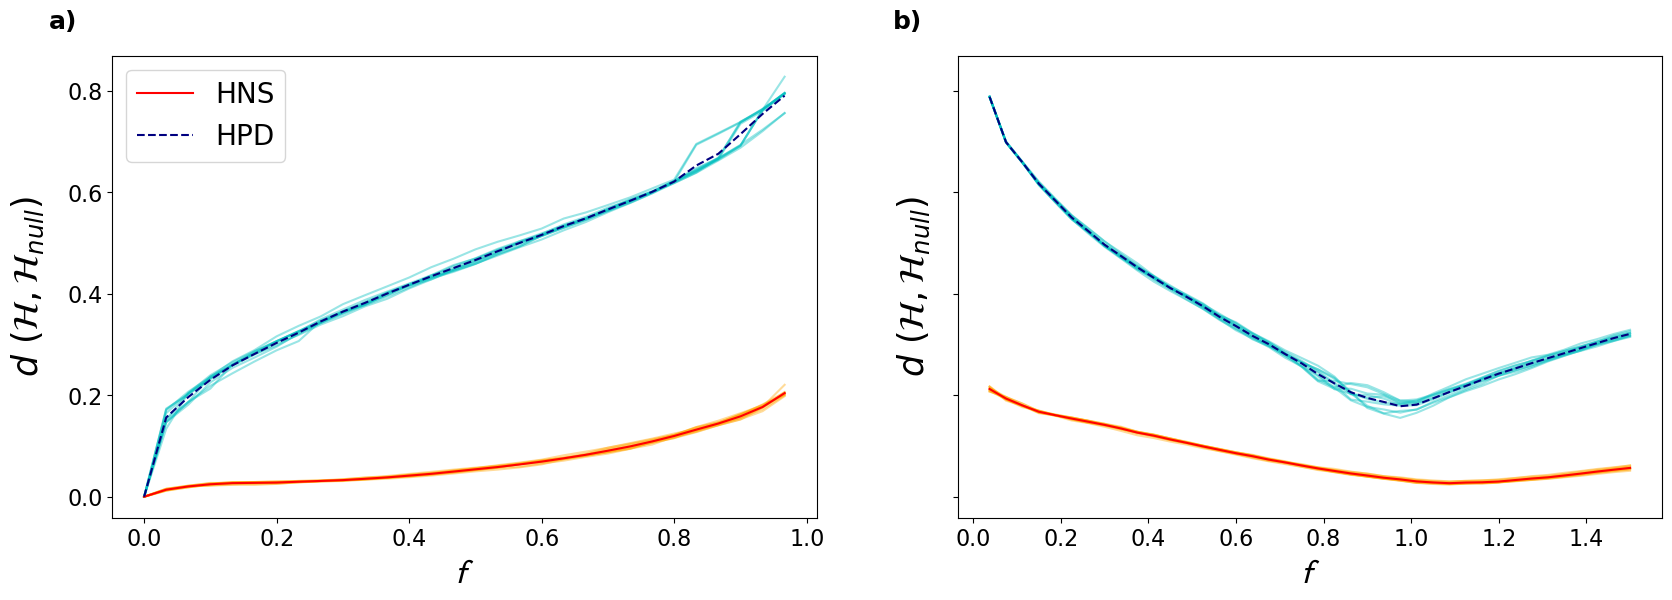

In [6]:
label_size = 25
mpl.style.use('default')
fig, axs = plt.subplots(1, 2, figsize=(20,6), sharey=True)

for i in range(2): 

    nm = ['rhp','rcp'][i]
    with open(f"../results/null_{nm}_HNS_HPD_SocioPatterns_LH10.json", "r") as fp:
        data_lists = json.load(fp)
    x = data_lists[0]
    HNS_curves = data_lists[1]
    HPD_curves = data_lists[2]
    
    for j in range(len(HNS_curves)):
        axs[i].plot(x, HNS_curves[j], color='orange', linestyle='-', alpha=0.4)
        axs[i].plot(x, HPD_curves[j], color='c', linestyle='-', alpha=0.4)
    
    axs[i].plot(x, np.mean(HNS_curves, axis=0), color='r', linestyle='-', label='HNS')
    axs[i].plot(x, np.mean(HPD_curves, axis=0), color='navy', linestyle='--', label='HPD')
    axs[i].tick_params(axis='both', labelsize=tick_size)
    axs[i].set_ylabel(r'$d\ (\mathcal{H}, \mathcal{H}_{null})$', fontsize=label_size, labelpad=15)
    axs[i].set_xlabel(r'$\mathcal{f}$', fontsize=label_size)


axs[0].legend(fontsize=20)

subplot_labels = ['a)', 'b)']
for ax, label in zip(axs, subplot_labels):
    ax.text(-0.05, 1.1, label, transform=ax.transAxes, fontsize=title_size, fontweight='bold', va='top', ha='right')

plt.savefig('../figures/fig_prj_null_model_LH10', dpi=dpi)
plt.show()

# 2 - Clustering of hypergraph models
## 2.1 - ER, CM, WS models

In [83]:
with open('../results/HNS_HPD_NS_PD_distances_models.json') as file:
    res = json.load(file)

labels = res[0]
dists = [res[i] for i in range(1,5)]

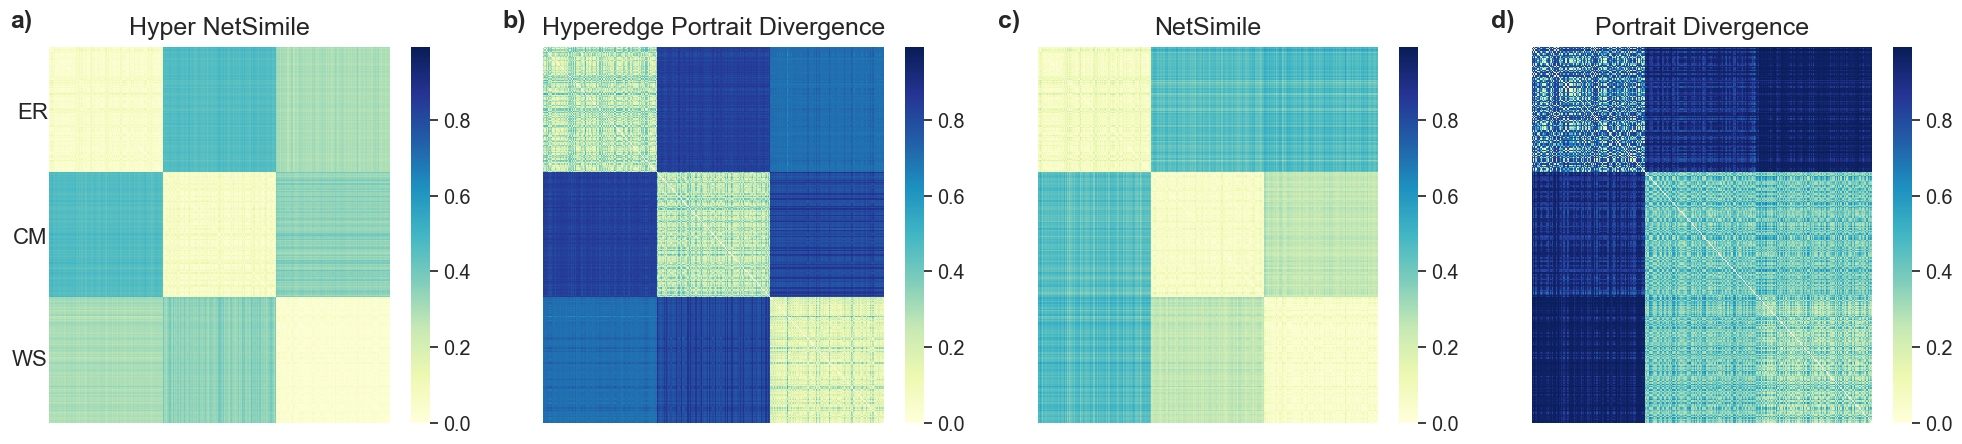

In [85]:
fig, axs = plt.subplots(1,4, figsize=(20, 4.7))
    
axs[0].set_title('Hyper NetSimile', fontsize=title_size, y=1.01)
axs[1].set_title('Hyperedge Portrait Divergence', fontsize=title_size, y=1.01)
axs[2].set_title('NetSimile', fontsize=title_size, y=1.01)
axs[3].set_title('Portrait Divergence', fontsize=title_size, y=1.01)
sb.set(font_scale=1.3)

# set same colorbar for all subplots
values = np.hstack([np.ravel(d) for d in dists])
norm = mpl.colors.Normalize(0, values.max()) 

for i in range(len(dists)):
    sb.heatmap(distance.squareform(dists[i]), cmap='YlGnBu', ax=axs[i],
               norm=norm, xticklabels=False, yticklabels=False)

# Define group positions and labels
group_positions = [(0,105), (0, 305), (0,500)]
group_labels = ["ER", "CM", "WS"]

# Add model labels to axs[0]
add_labels(axs[0], group_positions, group_labels)

# Add subplot labels
subplot_labels = ['a)', 'b)', 'c)', 'd)']
for ax, label in zip(axs, subplot_labels):
    ax.text(-0.05, 1.1, label, transform=ax.transAxes, fontsize=title_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../figures/fig_sim_matrices_models', dpi=dpi)
plt.show()

In [87]:
# compute Rand and Dunn Index
n_clst = 3
n_samp = int(len(labels) / n_clst)
true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
methods = ['single', 'average']

for method in methods:
    print(f'method: {method}')
    RI, DI = [], []
    for d in dists:
        zz = hierarchy.linkage(np.array(d), method)
        pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
        RI.append(rand_score(true_labels, pred_labels) )
        DI.append(DunnIndex(d, n_clst, method))

    print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

method: single
Rand index:  [1.0, 1.0, 1.0, 0.7770568561872909] 
Dunn's  index:    [1.4840835503755565, 1.0860684418395286, 0.7765563566367193, 0.3190346293849284] 

method: average
Rand index:  [1.0, 1.0, 1.0, 0.7375473801560758] 
Dunn's  index:    [1.4840835503755565, 1.0860684418395286, 0.7765563566367193, 0.1741416026681405] 



## 2.2 - ER models with different hyperedge sizes

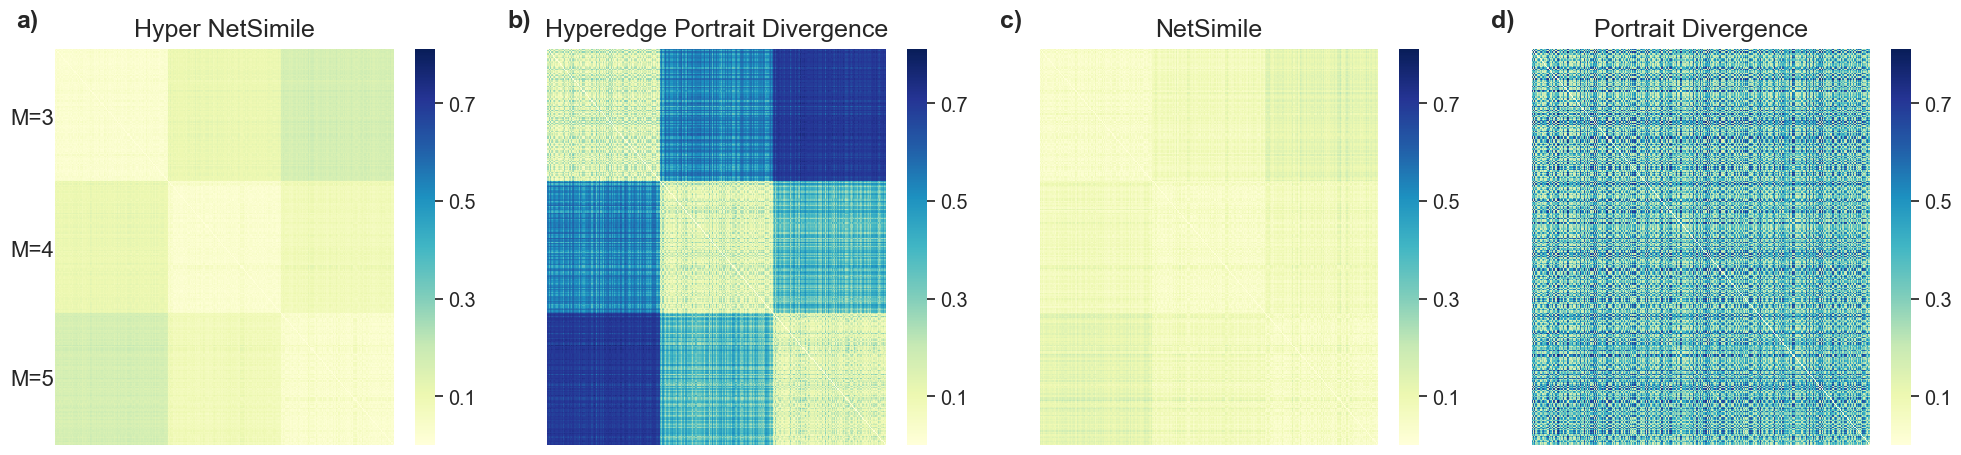

In [19]:
Ms = '3_4_5'
with open(f'../results/HNS_HPD_NS_PD_distances_ERs_{Ms}.json') as file:
    res = json.load(file)
labels = res[0]
dists = [res[i] for i in range(1,5)]

fig, axs = plt.subplots(1,4, figsize=(20, 4.8))
    
axs[0].set_title('Hyper NetSimile', fontsize=title_size, y=1.01)
axs[1].set_title('Hyperedge Portrait Divergence', fontsize=title_size, y=1.01)
axs[2].set_title('NetSimile', fontsize=title_size, y=1.01)
axs[3].set_title('Portrait Divergence', fontsize=title_size, y=1.01)
sb.set(font_scale=1.3)

# set same colorbar for all subplots
values = np.hstack([np.ravel(d) for d in dists])
norm = mpl.colors.Normalize(0, values.max()) 

for i in range(len(dists)):
    sb.heatmap(distance.squareform(dists[i]), cmap='YlGnBu', ax=axs[i], 
               norm=norm, xticklabels=False, yticklabels=False)
    axs[i].collections[0].colorbar.set_ticks([0.1,0.3,0.5,0.7])

# Define group positions and labels
group_positions = [(0,105), (0, 305), (0,500)]
group_labels = [f'M={Ms[0]}', f'M={Ms[2]}', f'M={Ms[4]}']

# Add model labels to axs[0]
add_labels(axs[0], group_positions, group_labels=group_labels)

# Add subplot labels
subplot_labels = ['a)', 'b)', 'c)', 'd)']
for ax, label in zip(axs, subplot_labels):
    ax.text(-0.05, 1.1, label, transform=ax.transAxes, fontsize=title_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig(f'../figures/fig_sim_matrices_ERs_{Ms}', dpi=dpi)
plt.show()

In [21]:
# compute Rand and Dunn Index
n_clst = 3
n_samp = int(len(labels) / n_clst)
true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
methods = ['single', 'average']

for method in methods:
    print(f'method: {method}')
    RI, DI = [], []
    for d in dists:

        zz = hierarchy.linkage(np.array(d), method)
        pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
        RI.append(rand_score(true_labels, pred_labels) )
        DI.append(DunnIndex(d, n_clst, method))

    print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

method: single
Rand index:  [1.0, 1.0, 0.3355852842809365, 0.3356298773690078] 
Dunn's  index:    [0.42199557139036264, 0.6042365680679602, 0.13420360579279686, 0.257029951597265] 

method: average
Rand index:  [1.0, 1.0, 0.7706354515050168, 0.5438573021181717] 
Dunn's  index:    [0.42199557139036264, 0.6042365680679602, 0.15008076412154112, 0.21810659282896483] 



# 3 - Clustering of reshuffling methods
## 3.1 - LH10 dataset

In [24]:
with open('../results/reshuffling_HNS_HPD_NS_PD_SocioPatterns_LH10.json') as file:
    res = json.load(file)
    
labels = res[0]
a = len(labels)-1

dists = [res[i][a:] for i in range(1,5)]
# isolate distances between orignal hypergraph and null models
dists_orig = [res[i][:a] for i in range(1,5)]

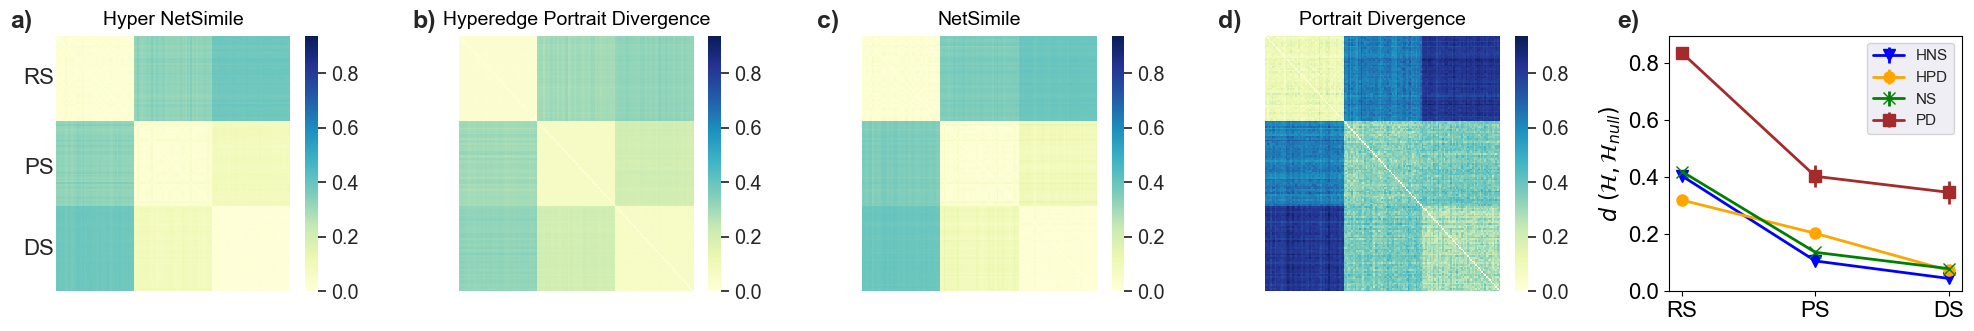

In [26]:
title_size2 = 14

mpl.style.use('default')
fig, axs = plt.subplots(1,5, figsize=(20, 3.6))
    
axs[0].set_title('Hyper NetSimile', fontsize=title_size2, y=1.01)
axs[1].set_title('Hyperedge Portrait Divergence', fontsize=title_size2, y=1.01)
axs[2].set_title('NetSimile', fontsize=title_size2, y=1.01)
axs[3].set_title('Portrait Divergence', fontsize=title_size2, y=1.01)
sb.set(font_scale=1.3)

# set same colorbar for all subplots
values = np.hstack([np.ravel(d) for d in dists])
norm = mpl.colors.Normalize(0, values.max()) 

for i in range(len(dists)):
    sb.heatmap(distance.squareform(dists[i]), cmap='YlGnBu', ax=axs[i],
               norm=norm, xticklabels=False, yticklabels=False)

# Define group positions and labels for reshuffling methods
group_positions = [(0, 50), (0, 155), (0,250)]
group_labels = ["RS", "PS", "DS"]

# Add model labels to axs[0]
add_labels(axs[0], group_positions, group_labels=group_labels)

# Last plot
L = int(len(dists_orig[0])/3)
axs[4].set_ylabel(r'$d\ (\mathcal{H}, \mathcal{H}_{null})$', fontsize=tick_size)

x = [1,2,3]
colors = ['blue', 'orange', 'green', 'brown']
d_labels = ['HNS', 'HPD', 'NS', 'PD']
markers = ['v','o','x','s']
for (clr, d, lab, mrk) in zip(colors, dists_orig, d_labels, markers):
    d_slices = [d[:L], d[L:2*L], d[2*L:]]
    y = [np.mean(d_s) for d_s in d_slices]
    yerr = [np.std(d_s) for d_s in d_slices]
    axs[4].errorbar(x, y, yerr, ecolor=clr, c=clr, lw=2, marker=mrk, markersize=8, label=lab)

axs[4].legend(fontsize=11)
axs[4].set_xticks(x)
axs[4].set_xticklabels(['RS', 'PS', 'DS'])
axs[4].tick_params(which='major', labelsize=tick_size)

# Add subplot labels
subplot_labels = ['a)', 'b)', 'c)', 'd)', 'e)']
for ax, label in zip(axs, subplot_labels):
    ax.text(-0.1, 1.1, label, transform=ax.transAxes, fontsize=title_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../figures/fig_reshuffling_LH10', dpi=dpi)
plt.show()

In [28]:
# compute Rand and Dunn Index
n_clst = 3
n_samp = int( (len(labels)-1) / n_clst )
true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
methods = ['single', 'average']

for method in methods:
    print(f'method: {method}')
    RI, DI = [], []
    for d in dists:

        zz = hierarchy.linkage(np.array(d), method)
        pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
        RI.append(rand_score(true_labels, pred_labels) )
        DI.append(DunnIndex(d, n_clst, method))

    print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

method: single
Rand index:  [1.0, 1.0, 1.0, 0.7763758389261745] 
Dunn's  index:    [0.9640520971697526, 2.493047232353369, 0.670328923019673, 0.5218903198679068] 

method: average
Rand index:  [1.0, 1.0, 1.0, 0.9911409395973154] 
Dunn's  index:    [0.9640520971697526, 2.493047232353369, 0.670328923019673, 0.47822264662669184] 



## 3.3 - Other datasets

Utah_elem_day2_0h-12h 

method: single
Rand index:  [1.0, 1.0, 0.7777181208053692, 0.7763758389261745] 
Dunn's  index:    [1.213174090366257, 4.105405023165435, 0.7523491834547036, 0.7719205808419091] 

method: average
Rand index:  [1.0, 1.0, 0.7777181208053692, 0.7763758389261745] 
Dunn's  index:    [1.213174090366257, 4.105405023165435, 0.7523491834547036, 0.7719205808419091] 

APS_PRD_1992_1996 

method: single
Rand index:  [1.0, 0.7676957494407158, 1.0, 0.7763758389261745] 
Dunn's  index:    [5.645752271543243, 0.3382325344247236, 2.7941345238849884, 0.8758109598464293] 

method: average
Rand index:  [1.0, 0.8679194630872483, 1.0, 0.9739597315436241] 
Dunn's  index:    [5.645752271543243, 0.26058630687895756, 2.7941345238849884, 0.8872825609942151] 

Online_music_blues_reviews 

method: single
Rand index:  [1.0, 0.7676957494407158, 1.0, 0.7719015659955257] 
Dunn's  index:    [2.036834123884691, 1.0623521250072343, 1.825239428296413, 0.6837444416488484] 

method: average
Rand index:

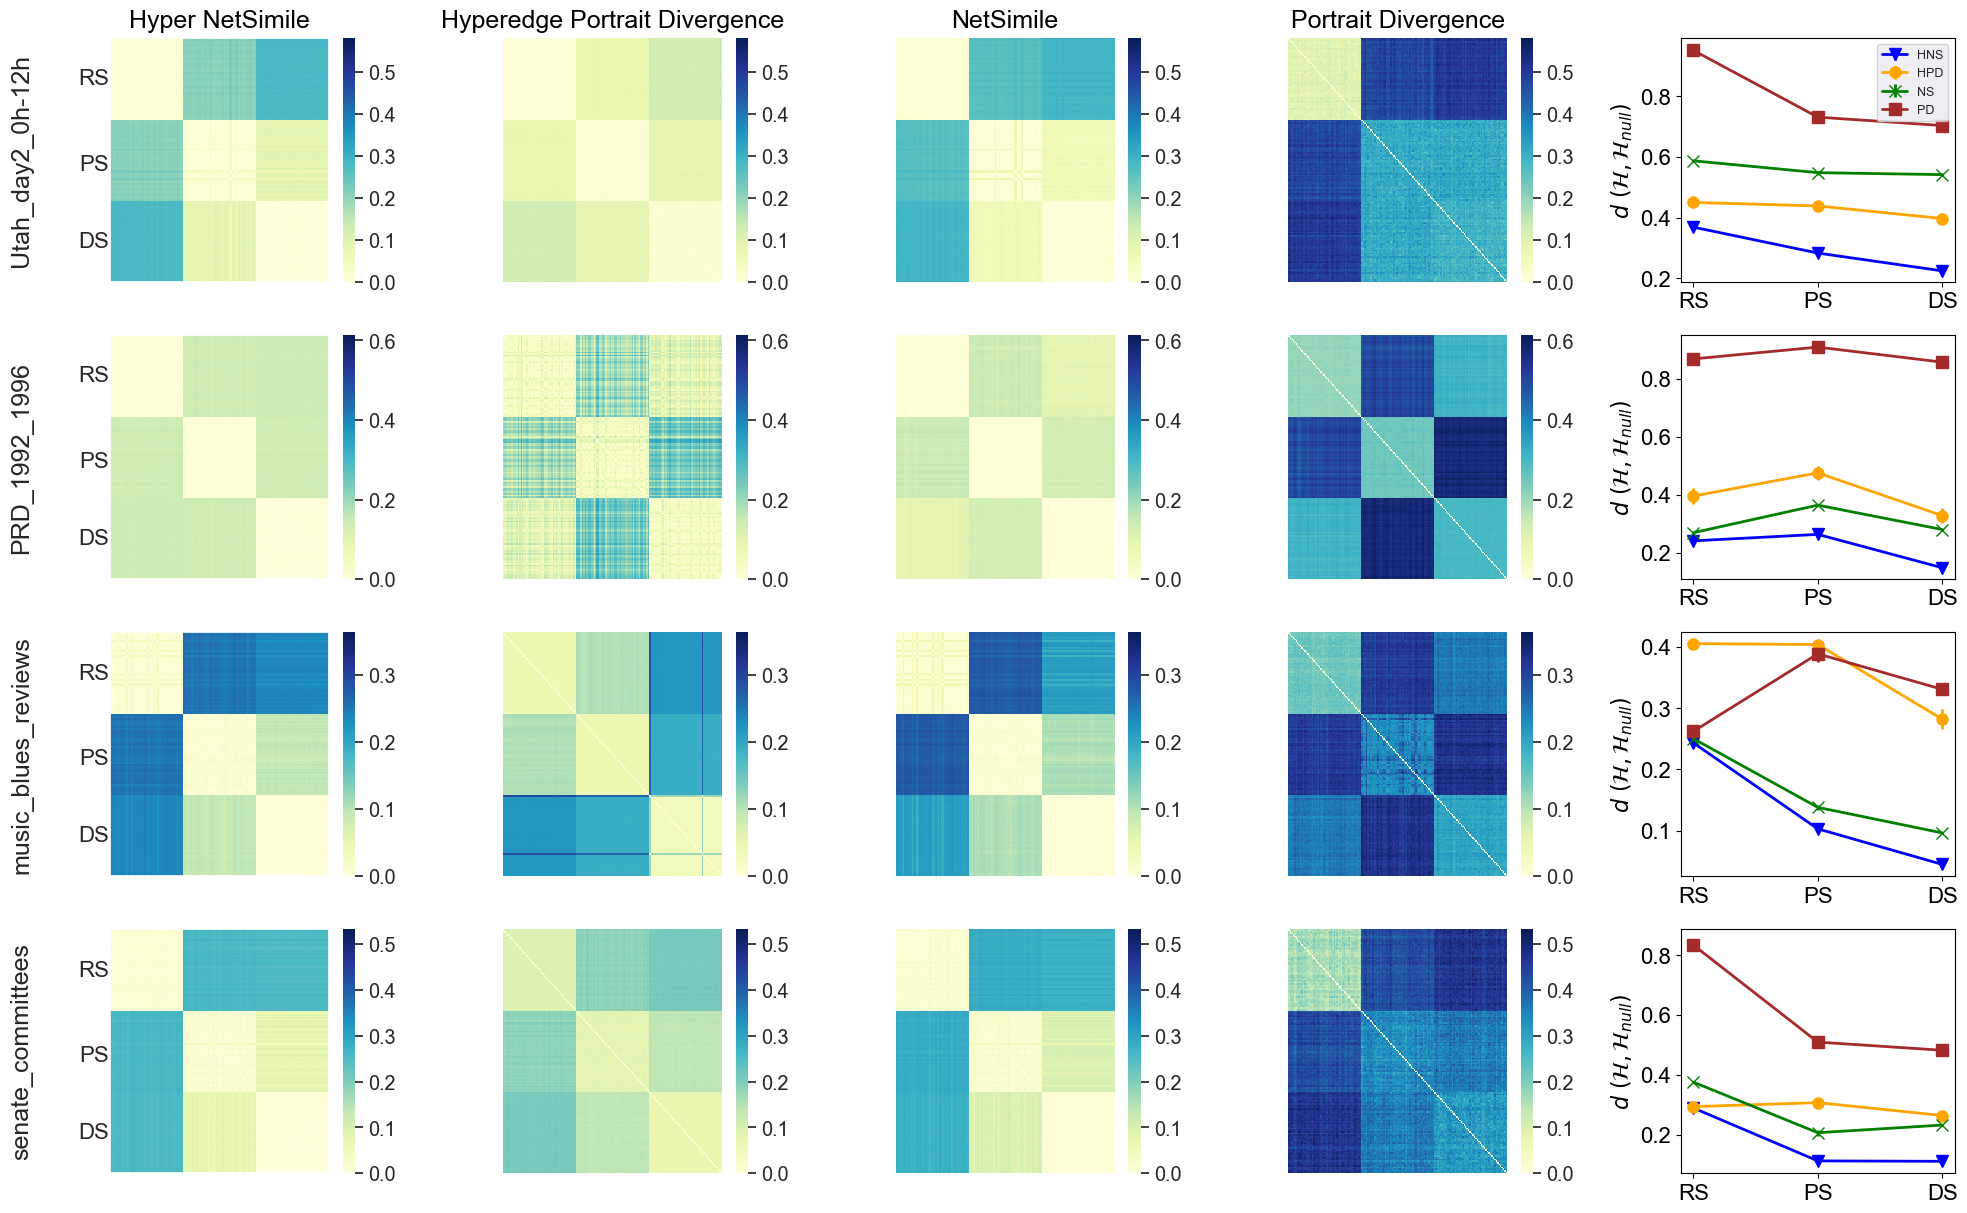

In [34]:
tags = ['Utah_elem_day2_0h-12h',  'APS_PRD_1992_1996', 
        'Online_music_blues_reviews', 'Congress_senate_committees',
       ]

mpl.style.use('default')
fig, axs = plt.subplots(len(tags), 5, figsize=(20,3.1*len(tags)))

titles = ['Hyper NetSimile', 'Hyperedge Portrait Divergence', 'NetSimile', 'Portrait Divergence']
for i in range(len(titles)):
    axs[0,i].set_title(titles[i], fontsize=title_size, y=1.01)
sb.set(font_scale=1.3)

for i in range(len(tags)):     
    # load data
    with open(f'../results/reshuffling_HNS_HPD_NS_PD_{tags[i]}.json') as file:
        res = json.load(file)        
    labels = res[0]
    a = len(labels)-1 
    dists = [res[i][a:] for i in range(1,5)]
    # isolate distances between orignal hypergraph and null models
    dists_orig = [res[i][:a] for i in range(1,5)]

    # set same colorbar for all subplots in same row
    values = np.hstack([np.ravel(d) for d in dists])
    norm = mpl.colors.Normalize(0, values.max())    
    for j in range(len(dists)):
        sb.heatmap(distance.squareform(dists[j]), cmap='YlGnBu', ax=axs[i,j],
                   norm=norm, xticklabels=False, yticklabels=False)
        
    # Reshuffling method labels
    group_positions = [(0, 50), (0, 155), (0,250)]
    labels_sh = ['RS', 'PS', 'DS']
    
    # Add model labels to axs[0]
    add_labels(axs[i,0], group_positions, group_labels=labels_sh)
    
    # Last column plots
    colors = ['blue', 'orange', 'green', 'brown']
    d_labels = ['HNS', 'HPD', 'NS', 'PD']
    markers = ['v','o','x','s']
    L = int(len(dists_orig[0])/3)  
    for (clr, d, lab, mrk) in zip(colors, dists_orig, d_labels, markers):
        d_slices = [d[:L], d[L:2*L], d[2*L:]]
        y = [np.mean(d_s) for d_s in d_slices]
        yerr = [np.std(d_s) for d_s in d_slices]
        x = [1,2,3]
        axs[i,4].errorbar(x, y, yerr, ecolor=clr, c=clr, lw=2, marker=mrk, markersize=8, label=lab)        
    axs[i,4].set_ylabel(r'$d\ (\mathcal{H}, \mathcal{H}_{null})$', fontsize=tick_size)
    axs[i,4].set_xticks(ticks=x, labels=labels_sh)
    axs[i,4].tick_params(which='major', labelsize=tick_size)

    # add dataset labels
    d_lbl = tags[i].replace('Congress_','').replace('APS_','').replace('elem_','').replace('Online_','')
    ax2 = axs[i,0].twinx()
    ax2.set_ylabel(f'{d_lbl}', fontsize=title_size, labelpad=-230)
    ax2.set_yticks([])

    # compute Rand and Dunn Index
    n_clst = 3
    n_samp = int( (len(labels)-1) / n_clst )
    true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
    methods = ['single', 'average']
    print(f'{tags[i]} \n')
    for method in methods:
        print(f'method: {method}')
        RI, DI = [], []
        for d in dists: 
            zz = hierarchy.linkage(np.array(d), method)
            pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
            RI.append(rand_score(true_labels, pred_labels) )
            DI.append(DunnIndex(d, n_clst, method))  
        print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

axs[0,4].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/fig_reshuffling_datasets', dpi=dpi)
plt.show()

# 4 - Weighted projection: models + LH10

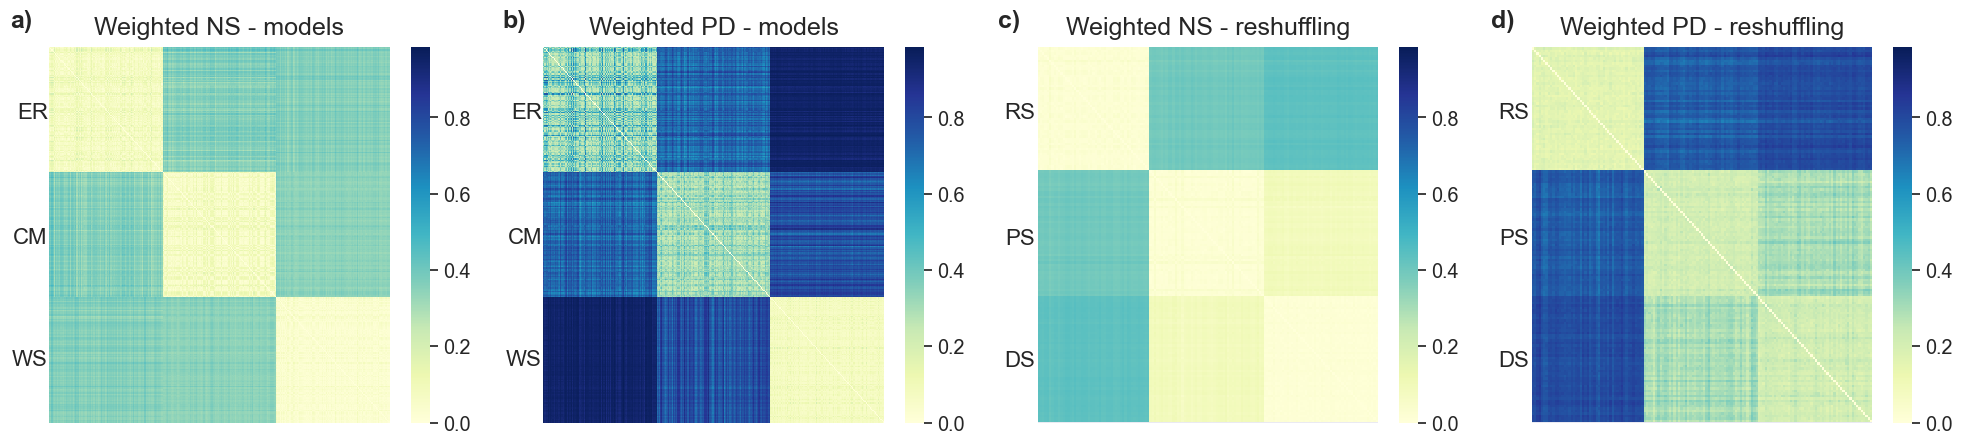

In [48]:
with open('../results/NS_PD_weighted_distances_models.json') as file:
    res = json.load(file)
labels = res[0]
dists = [res[1], res[2]]

with open('../results/reshuffling_NS_PD_weighted_SocioPatterns_LH10.json') as file:
    res = json.load(file)
 
labels2 = res[0]
a = len(labels)-1
dists += [res[1][a:], res[2][a:]]
# isolate distances between orignal hypergraph and null models
dists_orig = [res[1][:a], res[2][:a]]

fig, axs = plt.subplots(1,4, figsize=(20, 4.7))
    
axs[0].set_title('Weighted NS - models', fontsize=title_size, y=1.01)
axs[1].set_title('Weighted PD - models', fontsize=title_size, y=1.01)
axs[2].set_title('Weighted NS - reshuffling', fontsize=title_size, y=1.01)
axs[3].set_title('Weighted PD - reshuffling', fontsize=title_size, y=1.01)
sb.set(font_scale=1.3)

# set same colorbar for all subplots
values = np.hstack([np.ravel(d) for d in dists])
norm = mpl.colors.Normalize(0, values.max()) 

for i in range(len(dists)):
    sb.heatmap(distance.squareform(dists[i]), cmap='YlGnBu', ax=axs[i],
               norm=norm, xticklabels=False, yticklabels=False)

# Add model labels to axs[0]
group_positions = [(0,105), (0, 305), (0,500)]
group_labels = ["ER", "CM", "WS"]
add_labels(axs[0], group_positions, group_labels)
add_labels(axs[1], group_positions, group_labels)

# Add model labels to axs[2]
group_positions = [(0,52), (0, 152), (0,249)]
group_labels = ["RS", "PS", "DS"]
add_labels(axs[2], group_positions, group_labels)
add_labels(axs[3], group_positions, group_labels)

# Add subplot labels
subplot_labels = ['a)', 'b)', 'c)', 'd)']
for ax, label in zip(axs, subplot_labels):
    ax.text(-0.05, 1.1, label, transform=ax.transAxes, fontsize=title_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../figures/fig_sim_matrices_NS_PD_weighted', dpi=dpi)
plt.show()

## 4.1 - Weighted projection of hypergraph models

In [9]:
with open('../results/NS_PD_weighted_distances_models.json') as file:
    res = json.load(file)
labels = res[0]
dists = [res[1], res[2]]

# compute Rand and Dunn Index
n_clst = 3
n_samp = int(len(labels) / n_clst)
true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
methods = ['single', 'average']

for method in methods:
    print(f'method: {method}')
    RI, DI = [], []
    for d in dists:
        zz = hierarchy.linkage(np.array(d), method)
        pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
        RI.append(rand_score(true_labels, pred_labels) )
        DI.append(DunnIndex(d, n_clst, method))

    print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

method: single
Rand index:  [1.0, 1.0] 
Dunn's  index:    [1.1109498026060507, 0.69455914171264] 

method: average
Rand index:  [1.0, 1.0] 
Dunn's  index:    [1.1109498026060507, 0.69455914171264] 



## 4.2 - Weighted projection of LH10 dataset

In [31]:
with open('../results/reshuffling_NS_PD_weighted_SocioPatterns_LH10.json') as file:
    res = json.load(file)
 
labels = res[0]
a = len(labels)-1

dists = [res[1][a:], res[2][a:]]
# isolate distances between orignal hypergraph and null models
dists_orig = [res[1][:a], res[2][:a]]

# compute Rand and Dunn Index
n_clst = 3
n_samp = int(len(labels) / n_clst)
true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
methods = ['single', 'average']

for method in methods:
    print(f'method: {method}')
    RI, DI = [], []
    for d in dists:
        zz = hierarchy.linkage(np.array(d), method)
        pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
        RI.append(rand_score(true_labels, pred_labels) )
        DI.append(DunnIndex(d, n_clst, method))

    print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

method: single
Rand index:  [1.0, 0.7763758389261745] 
Dunn's  index:    [0.750626010610845, 0.5204625756935385] 

method: average
Rand index:  [1.0, 1.0] 
Dunn's  index:    [0.750626010610845, 0.6917795428392022] 



# 5 - Clustering of real-world hypergraphs

In [37]:
with open('../results/HNS_HPD_NS_PD_distances_data.json') as file:
    res = json.load(file) 
labels = res[0]
dists = [res[i] for i in range(1,5)]

labels = [
    l.replace('SocioPatterns_', '').replace('APS_', '').replace('elem_', ''
    ).replace('Online_', '').replace('Congress_', '').replace('Conferences_', '')
    for l in labels ]

In [39]:
# Assign colors to labels for dendrograms
label_colors = dict()
for l in labels:
    if l.startswith('PR'):
        label_colors[l] = 'firebrick'
    elif l.startswith('hou') or l.startswith('sen'):
        label_colors[l] = 'dodgerblue'
    elif l.startswith('mus') or l.startswith('geo') or l.startswith('alg'):
        label_colors[l] = 'darkorange'
    elif l.startswith('Utah'):
        label_colors[l] = 'darkgreen'
    elif l.startswith('CopNS'):
        label_colors[l] = 'slategray'
    else:
        label_colors[l] = 'navy'

## 5.1 - "Minimum" clustering algorithm

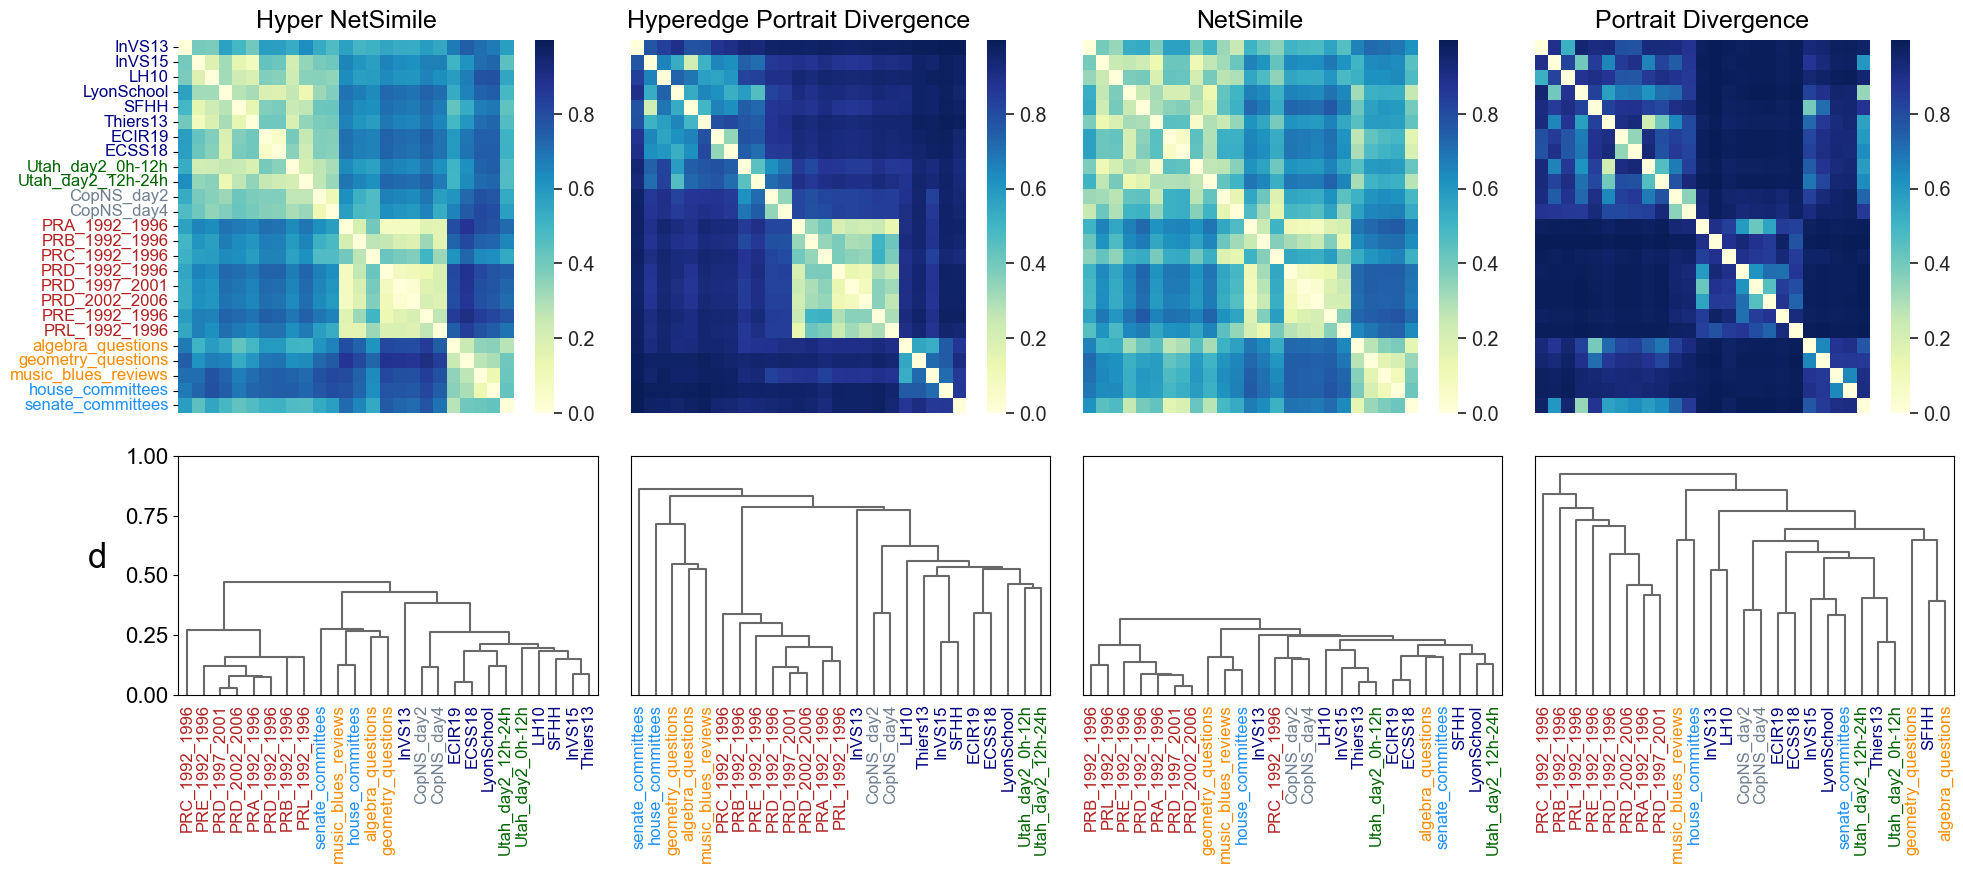

In [42]:
leaf_size = 12
mpl.style.use('default')
fig, axs = plt.subplots(2,4, figsize=(20, 9), gridspec_kw={'height_ratios': [25,16]})
    
titles = ['Hyper NetSimile', 'Hyperedge Portrait Divergence', 'NetSimile', 'Portrait Divergence']
sb.set(font_scale=1.3)

# set same colorbar for all subplots
values = np.hstack([np.ravel(d) for d in dists])
norm = mpl.colors.Normalize(0, values.max()) 
mtd = 'single'

for i in range(len(dists)):
    ytl = False
    if i==0:
        ytl=True
    sb.heatmap(distance.squareform(dists[i]), cmap='YlGnBu', ax=axs[0,i], norm=norm, 
               xticklabels=False, yticklabels=ytl)
    axs[0,i].set_title(titles[i], fontsize=title_size, y=1.01)

    Z = hierarchy.linkage(np.array(dists[i]), method=mtd)
    hierarchy.dendrogram(Z, leaf_rotation=90, ax=axs[1,i], labels=labels,
                         leaf_font_size=leaf_size, distance_sort='ascending',
                         color_threshold=0, above_threshold_color='dimgray')
    axs[1,i].set_ylim(0,1)
    axs[1,i].set_yticks([])
    xlbls = axs[1,i].get_xmajorticklabels()
    for lbl in xlbls:
        lbl.set_color(label_colors[lbl.get_text()])

# add dataset labels
axs[0,0].set_yticklabels(labels, fontsize=leaf_size)

# set label colors in first subplot
y_lbl0 = axs[0,0].get_ymajorticklabels()
for j in range(len(y_lbl0)):
    lbl = y_lbl0[j]
    lbl.set_color(label_colors[labels[j]])
    
y_dendr = [0,0.25,0.50,0.75,1.00]
axs[1,0].set_yticks(y_dendr)
axs[1,0].tick_params(axis='y', labelsize=tick_size)
axs[1,0].set_ylabel('d', fontsize=label_size, rotation=0, labelpad=20)

plt.tight_layout()
plt.savefig(f'../figures/fig_sim_matrices_dendro_{mtd}_data', dpi=dpi)
plt.show()

## 5.2 - "Average" clustering algorithm

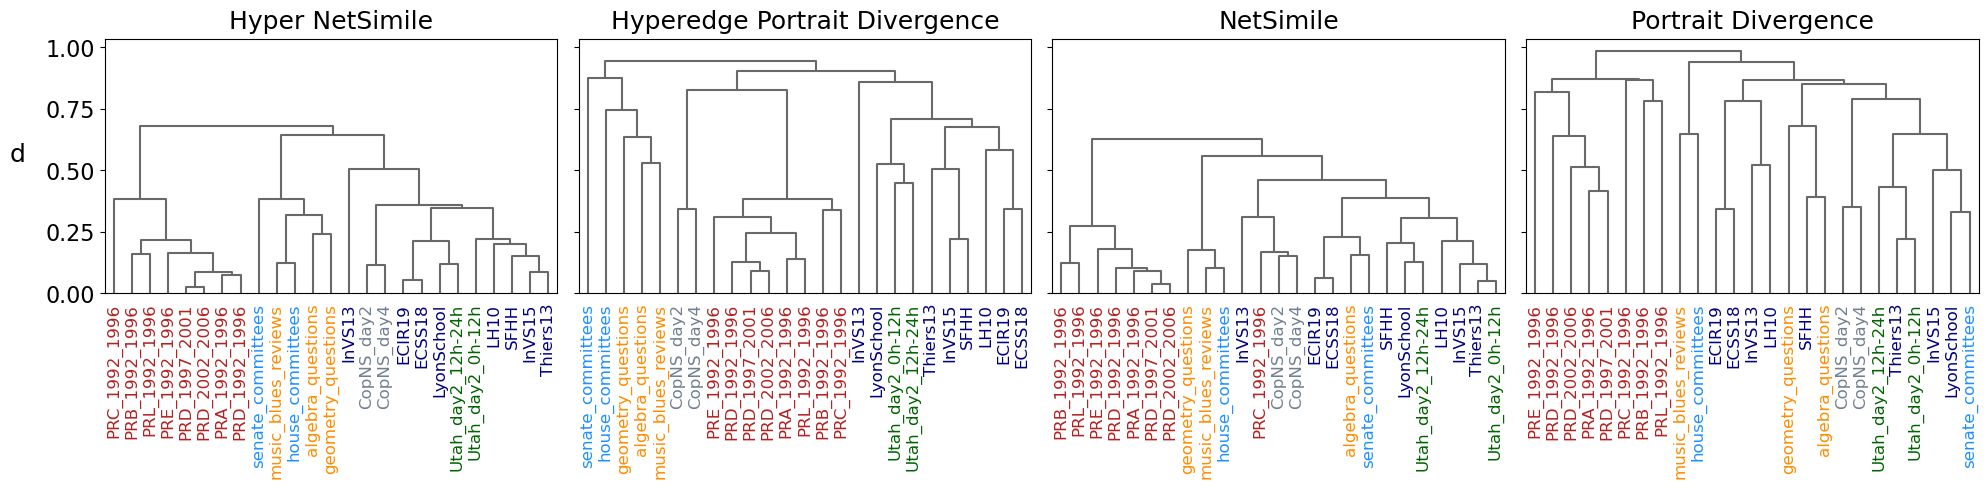

In [45]:
mpl.style.use('default')
mtd = 'average'
fig, axs = plt.subplots(1, 4, sharey=True, figsize=(20, 5))

titles = ['Hyper NetSimile', 'Hyperedge Portrait Divergence', 'NetSimile', 'Portrait Divergence']

# plot dendrograms
for j in range(len(dists)):
    Z = hierarchy.linkage(np.array(dists[j]), method=mtd)
    hierarchy.dendrogram(Z, leaf_rotation=90, ax=axs[j], labels=labels,
                         leaf_font_size=leaf_size, distance_sort='ascending',
                         color_threshold=0, above_threshold_color='dimgray')
    axs[j].set_title(titles[j], fontsize=title_size, y=1.01)
    xlbls = axs[j].get_xmajorticklabels()
    for lbl in xlbls:
        lbl.set_color(label_colors[lbl.get_text()])

y_dendr = [0,0.25,0.50,0.75,1.00]
axs[0].set_yticks(y_dendr)
axs[0].tick_params(axis='y', labelsize=tick_size)
axs[0].set_ylabel('d', fontsize=title_size, rotation=0, labelpad=20)


plt.tight_layout()
plt.savefig(f'../figures/fig_dendro_{mtd}_data', dpi=dpi)
plt.show()

# 6 - Alternative formulations of HNS and NS

In [97]:
with open('../results/HNS_NS_distances_models_skew_kurt.json') as file:
    res = json.load(file)
dists = [res[1], res[2]]

with open('../results/HNS_distances_models_with_clst.json') as file:
    res2 = json.load(file)
dists.append(res2[1])

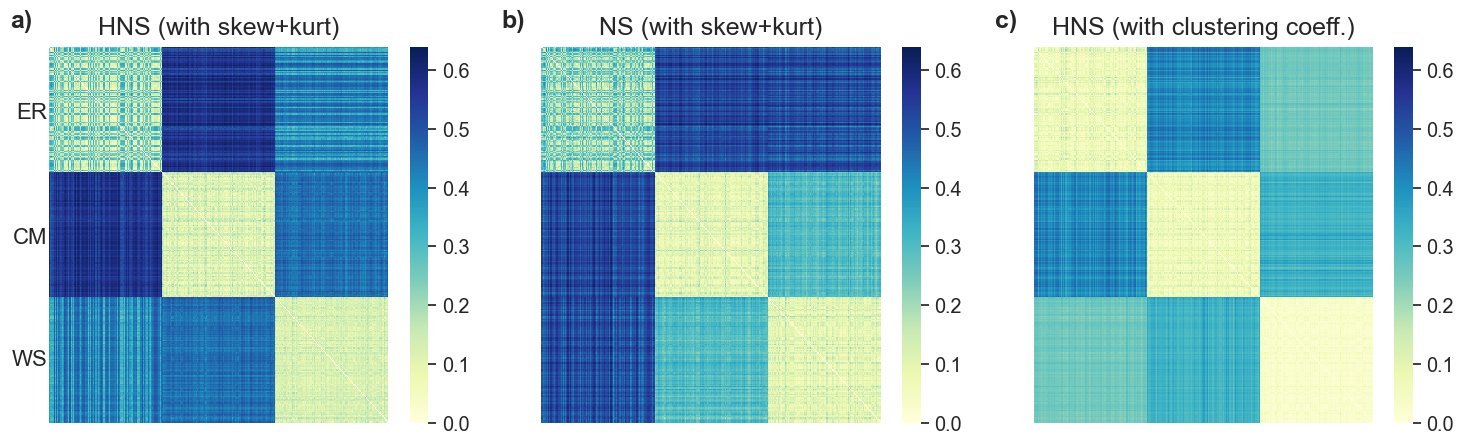

In [105]:
fig, axs = plt.subplots(1,3, figsize=(15, 4.7))
    
axs[0].set_title('HNS (with skew+kurt)', fontsize=title_size, y=1.01)
axs[1].set_title('NS (with skew+kurt)', fontsize=title_size, y=1.01)
axs[2].set_title('HNS (with clustering coeff.)', fontsize=title_size, y=1.01)
sb.set(font_scale=1.3)

# set same colorbar for all subplots
values = np.hstack([np.ravel(d) for d in dists])
norm = mpl.colors.Normalize(0, values.max()) 

for i in range(len(dists)):
    sb.heatmap(distance.squareform(dists[i]), cmap='YlGnBu', ax=axs[i],
               norm=norm, xticklabels=False, yticklabels=False)

# Define group positions and labels
group_positions = [(0,105), (0, 305), (0,500)]
group_labels = ["ER", "CM", "WS"]

# Add model labels to axs[0]
add_labels(axs[0], group_positions, group_labels)

# Add subplot labels
subplot_labels = ['a)', 'b)', 'c)']
for ax, label in zip(axs, subplot_labels):
    ax.text(-0.05, 1.1, label, transform=ax.transAxes, fontsize=title_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('../figures/fig_sim_matrices_models_HNS_NS_skew_kurt_clust', dpi=dpi)
plt.show()

In [107]:
# compute Rand and Dunn Index
n_clst = 3
n_samp = int(len(labels) / n_clst)
true_labels = np.ravel( [[l]*n_samp for l in range(n_clst)] )
methods = ['single', 'average']

for method in methods:
    print(f'method: {method}')
    RI, DI = [], []
    for d in dists:
        zz = hierarchy.linkage(np.array(d), method)
        pred_labels = hierarchy.cut_tree(zz, n_clusters=n_clst).flatten()
        RI.append(rand_score(true_labels, pred_labels) )
        DI.append(DunnIndex(d, n_clst, method))

    print("Rand index: ", RI, "\nDunn's  index:   ", DI, '\n')

method: single
Rand index:  [1.0, 1.0, 1.0] 
Dunn's  index:    [0.6200117163097852, 0.40387791255070227, 0.9892835161963165] 

method: average
Rand index:  [1.0, 1.0, 1.0] 
Dunn's  index:    [0.6200117163097852, 0.40387791255070227, 0.9892835161963165] 

